# SPARTAN vs IMPROVE — the shared-parameter comparison, remade in mass on filter

Remake of `spartan_vs_improve_comparison.ipynb` per the meeting decisions:

- **mass on filter (µg), not µg/m³, no log concentration axes** — the instrument sees the deposit, not the airflow;
- absorption appears as **filter optical depth tau = fAbs × V / A** (volume-free; deposit areas are
  3.5 cm² IMPROVE vs 3.53 cm² SPARTAN, effectively identical);
- canonical 4-site colors (Beijing red, Delhi blue, JPL green, Addis orange), IMPROVE in gray;
- SPARTAN is now **all 25 HIPS sites** (public ChemSpec × HIPS volume, thermal carbon — method-matched to
  IMPROVE), not just the core four;
- IMPROVE volume uses reported flow × duration where available; for pre-2015 rows (FED stops reporting flow
  there) it falls back to the **site-median flow** (network flow is tightly controlled: 21.3 L/min ± ~5%),
  so the discontinued urban sites stay in. Estimated-volume rows are flagged and counted.


## 0. Setup

In [1]:
import sys
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=FutureWarning)


def find_repo_root(start=None):
    p = Path(start or Path.cwd()).resolve()
    for cand in [p, *p.parents]:
        if (cand / "AGENTS.md").exists() and (cand / "research").exists():
            return cand
    raise RuntimeError("Could not locate repo root. CWD=%s" % Path.cwd())


REPO_ROOT = find_repo_root()
sys.path.insert(0, str(REPO_ROOT / "research/ftir_hips_chem/scripts"))
try:
    from plotting import apply_default_style
    from plotting.utils import calculate_regression_stats
    apply_default_style()
except Exception as e:
    print("plotting package unavailable (%s)" % e)

DRIVE = REPO_ROOT / "research/improve_hips_offset/data_improve/Data"
IMPROVE_CACHE = DRIVE / "Improve/improve_chemistry_clean_cache.pkl"
PUB_CACHE = DRIVE / "Spartan/public_chemspec_iron_cache.pkl"
HIPS_BATCH_CSV = DRIVE / "Spartan/SPARTAN_HIPS_Batch1-51.v2.csv"

OUT = REPO_ROOT / "research/spartan/improve_comparison_mass"
FIG_DIR = OUT / "figures"
TAB_DIR = OUT / "tables"
FIG_DIR.mkdir(parents=True, exist_ok=True)
TAB_DIR.mkdir(parents=True, exist_ok=True)

NET_COLORS = {"SPARTAN": "#111111", "IMPROVE": "0.62"}
SITE_COLORS = {"CHTS": "#E74C3C", "ETAD": "#F39C12", "INDH": "#3498DB", "USPA": "#2ECC71"}
SITE_NAMES = {"CHTS": "Beijing", "ETAD": "Addis Ababa", "INDH": "Delhi", "USPA": "Pasadena/JPL"}
CORE4 = ["ETAD", "INDH", "CHTS", "USPA"]
IMPROVE_AREA_CM2, SPARTAN_AREA_CM2 = 3.5, 3.53

# harmonized column -> (pretty label, unit)
SHARED = {
    "EC_mass_ug":   ("EC mass on filter", "µg"),
    "OC_mass_ug":   ("OC mass on filter", "µg"),
    "tau_filter":   ("filter optical depth tau", "–"),
    "Fe_mass_ug":   ("Fe mass on filter", "µg"),
    "PM25_mass_ug": ("PM₂.₅ mass on filter", "µg"),
}
print("Figures ->", FIG_DIR)

Figures -> /home/user/aethmodular/research/spartan/improve_comparison_mass/figures


## 1. Harmonize both networks into mass space

In [2]:
# --- IMPROVE, with the site-median-flow volume fallback ---
imp = pd.read_pickle(IMPROVE_CACHE)
flow_ok = imp["FlowRate_Val"].gt(0) & imp["SampDur_Val"].gt(0)
site_flow = imp.loc[flow_ok].groupby("SiteCode")["FlowRate_Val"].median()
net_flow = imp.loc[flow_ok, "FlowRate_Val"].median()
flow_est = imp["SiteCode"].map(site_flow).fillna(net_flow)
dur_est = imp["SampDur_Val"].where(imp["SampDur_Val"].gt(0), 1440.0)
imp["vol_estimated"] = ~flow_ok
imp["volume_m3"] = np.where(flow_ok, imp["FlowRate_Val"] * imp["SampDur_Val"] / 1000.0,
                            flow_est * dur_est / 1000.0)

improve = pd.DataFrame({
    "network": "IMPROVE", "site": imp["SiteCode"], "date": imp["Date"],
    "EC_ugm3": imp["ECf_Val"], "OC_ugm3": imp["OCf_Val"], "Fabs_Mm": imp["fAbs_Val"],
    "Fe_ugm3": imp["FEf_Val"], "PM25_ugm3": imp["MF_Val"],
    "volume_m3": imp["volume_m3"], "vol_estimated": imp["vol_estimated"],
})
improve["area_cm2"] = IMPROVE_AREA_CM2

# --- SPARTAN: public ChemSpec (thermal) x HIPS volume/fAbs, all HIPS sites ---
pub = pd.read_pickle(PUB_CACHE)
hips = pd.read_csv(HIPS_BATCH_CSV)
hips["SampleDate"] = pd.to_datetime(hips["SampleDate"], errors="coerce")
hips = hips[hips["FilterType"].eq("PM2.5") & np.isfinite(hips["Fabs"])]
m = pub.merge(hips[["Site", "SampleDate", "Fabs", "Volume"]], on=["Site", "SampleDate"], how="inner")

spartan = pd.DataFrame({
    "network": "SPARTAN", "site": m["Site"], "date": m["SampleDate"],
    "EC_ugm3": m["EC_thermal"], "OC_ugm3": m["OC_thermal"], "Fabs_Mm": m["Fabs"],
    "Fe_ugm3": m["Fe"], "PM25_ugm3": m["PM25"],
    "volume_m3": m["Volume"], "vol_estimated": False,
})
spartan["area_cm2"] = SPARTAN_AREA_CM2

both = pd.concat([improve, spartan], ignore_index=True)
for conc, mass in [("EC_ugm3", "EC_mass_ug"), ("OC_ugm3", "OC_mass_ug"),
                   ("Fe_ugm3", "Fe_mass_ug"), ("PM25_ugm3", "PM25_mass_ug")]:
    both[mass] = both[conc] * both["volume_m3"]
both["tau_filter"] = both["Fabs_Mm"] * 1e-6 * both["volume_m3"] / (both["area_cm2"] * 1e-4)

# volume-free ratios (unchanged by any of this)
both["OC_EC"] = np.where(both["EC_ugm3"] > 0, both["OC_ugm3"] / both["EC_ugm3"], np.nan)
both["Fabs_EC"] = np.where(both["EC_ugm3"] > 0, both["Fabs_Mm"] / both["EC_ugm3"], np.nan)
both["Fe_PM"] = np.where(both["PM25_ugm3"] > 0, 100 * both["Fe_ugm3"] / both["PM25_ugm3"], np.nan)

cov = (both.groupby("network")
       .agg(rows=("site", "size"), sites=("site", "nunique"),
            date_min=("date", "min"), date_max=("date", "max"),
            est_volume_rows=("vol_estimated", "sum")))
cov.to_csv(TAB_DIR / "coverage_summary.csv")
print(cov.to_string())
print(f"\nIMPROVE rows using estimated (site-median-flow) volume: "
      f"{100 * improve['vol_estimated'].mean():.0f}% — all pre-2015")

           rows  sites   date_min   date_max  est_volume_rows
network                                                      
IMPROVE  626513    237 1988-03-02 2025-07-30           442169
SPARTAN    2481     25 2022-04-26 2026-02-25                0

IMPROVE rows using estimated (site-median-flow) volume: 71% — all pre-2015


## Figure M1 — distribution boxplots by network, in mass (linear axes)

/tmp/ipykernel_4457/1878768943.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=["IMPROVE", "SPARTAN"], showfliers=False,
/tmp/ipykernel_4457/1878768943.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=["IMPROVE", "SPARTAN"], showfliers=False,


/tmp/ipykernel_4457/1878768943.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=["IMPROVE", "SPARTAN"], showfliers=False,
/tmp/ipykernel_4457/1878768943.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=["IMPROVE", "SPARTAN"], showfliers=False,


/tmp/ipykernel_4457/1878768943.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=["IMPROVE", "SPARTAN"], showfliers=False,


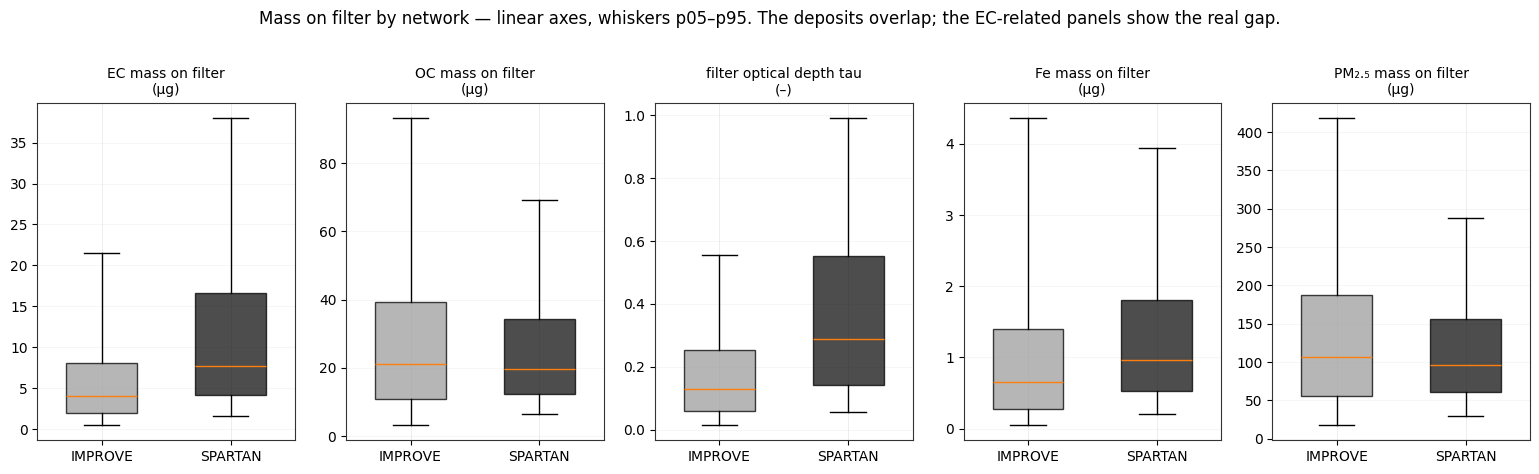

In [3]:
def pos(s):
    s = s.replace([np.inf, -np.inf], np.nan).dropna()
    return s[s > 0]


fig, axes = plt.subplots(1, 5, figsize=(15.5, 4.6))
stat_rows = []
for ax, (col, (label, unit)) in zip(axes, SHARED.items()):
    data, colors = [], []
    for net in ["IMPROVE", "SPARTAN"]:
        v = pos(both.loc[both["network"].eq(net), col])
        data.append(v.values)
        colors.append(NET_COLORS[net])
        stat_rows.append({"network": net, "quantity": label, "unit": unit, "n": len(v),
                          **{f"p{int(q*100):02d}": v.quantile(q) for q in [0.05, 0.25, 0.5, 0.75, 0.95]}})
    bp = ax.boxplot(data, labels=["IMPROVE", "SPARTAN"], showfliers=False,
                    patch_artist=True, whis=(5, 95), widths=0.55)
    for patch, c in zip(bp["boxes"], colors):
        patch.set_facecolor(c); patch.set_alpha(0.75)
    ax.set_title(f"{label}\n({unit})", fontsize=10)
    ax.grid(axis="y", alpha=0.25)
fig.suptitle("Mass on filter by network — linear axes, whiskers p05–p95. "
             "The deposits overlap; the EC-related panels show the real gap.", y=1.02)
fig.tight_layout()
fig.savefig(FIG_DIR / "M1_distribution_boxplots_mass.png", dpi=200, bbox_inches="tight")
plt.show()

pd.DataFrame(stat_rows).round(3).to_csv(TAB_DIR / "distribution_stats_mass.csv", index=False)

## Figure M2 — empirical CDFs in mass (linear axes, clipped at p99)

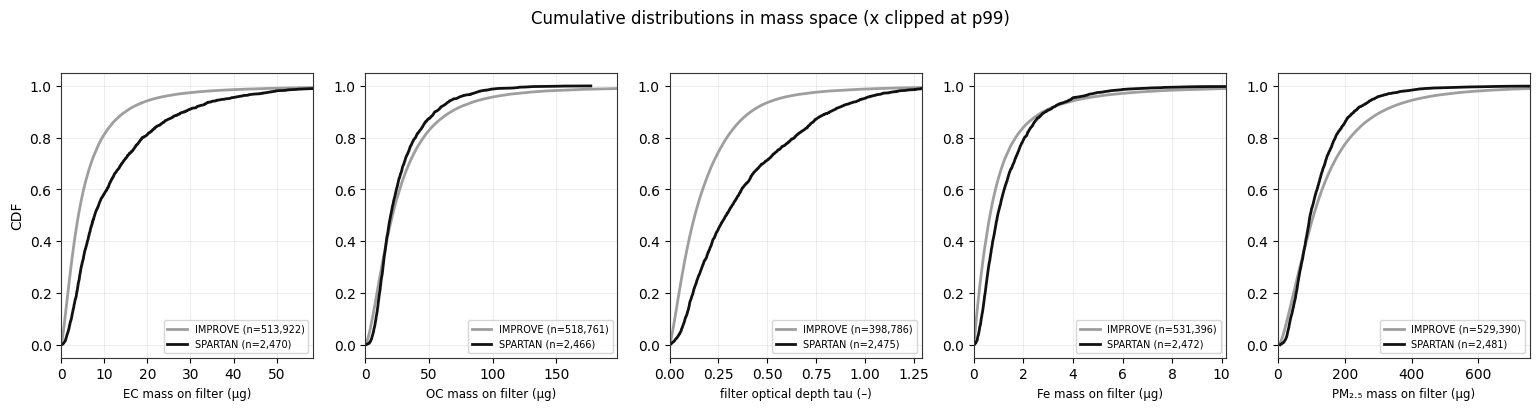

In [4]:
fig, axes = plt.subplots(1, 5, figsize=(15.5, 3.9))
for ax, (col, (label, unit)) in zip(axes, SHARED.items()):
    clip = max(pos(both.loc[both["network"].eq(n), col]).quantile(0.99) for n in ["IMPROVE", "SPARTAN"])
    for net in ["IMPROVE", "SPARTAN"]:
        v = np.sort(pos(both.loc[both["network"].eq(net), col]).values)
        ax.plot(v, np.linspace(0, 1, len(v)), color=NET_COLORS[net], lw=2,
                label=f"{net} (n={len(v):,})")
    ax.set_xlim(0, clip)
    ax.set_xlabel(f"{label} ({unit})", fontsize=8.5)
    ax.set_ylabel("CDF" if col == "EC_mass_ug" else "")
    ax.legend(fontsize=7)
fig.suptitle("Cumulative distributions in mass space (x clipped at p99)", y=1.04)
fig.tight_layout()
fig.savefig(FIG_DIR / "M2_distribution_cdf_mass.png", dpi=200, bbox_inches="tight")
plt.show()

## Figure M3 — the core four sites against the IMPROVE distribution

/tmp/ipykernel_4457/2669824542.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=[f"{s}" for s in CORE4], showfliers=False,


/tmp/ipykernel_4457/2669824542.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=[f"{s}" for s in CORE4], showfliers=False,


/tmp/ipykernel_4457/2669824542.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=[f"{s}" for s in CORE4], showfliers=False,


/tmp/ipykernel_4457/2669824542.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=[f"{s}" for s in CORE4], showfliers=False,


/tmp/ipykernel_4457/2669824542.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=[f"{s}" for s in CORE4], showfliers=False,


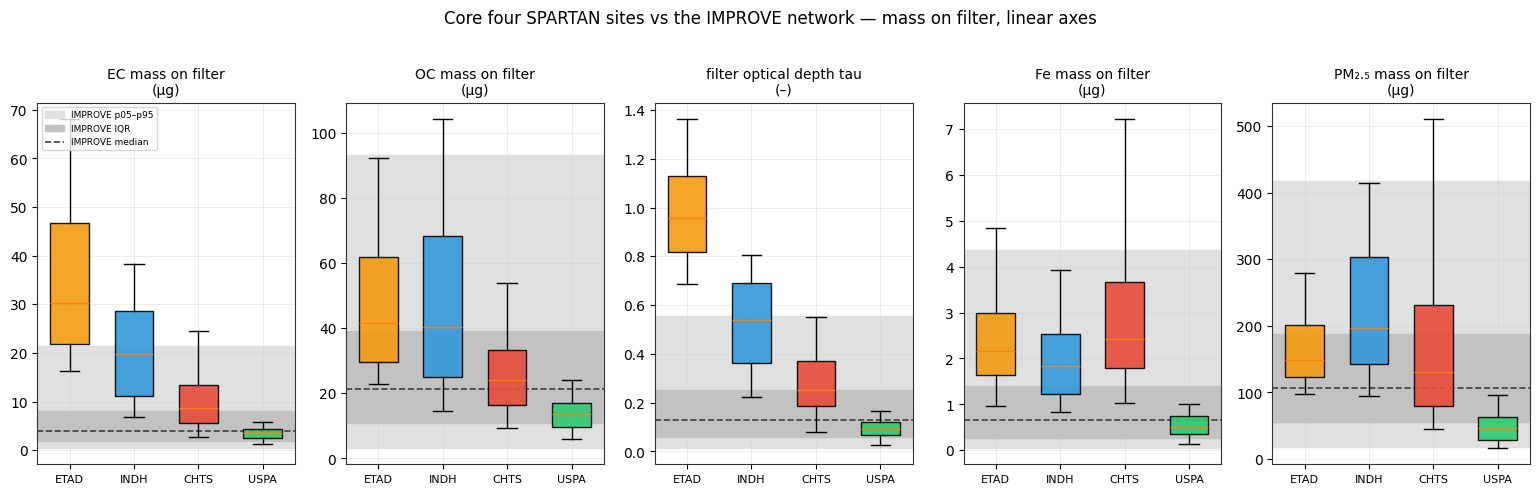

In [5]:
fig, axes = plt.subplots(1, 5, figsize=(15.5, 4.8))
for ax, (col, (label, unit)) in zip(axes, SHARED.items()):
    iv = pos(both.loc[both["network"].eq("IMPROVE"), col])
    ax.axhspan(iv.quantile(0.05), iv.quantile(0.95), color="0.88", zorder=0, label="IMPROVE p05–p95")
    ax.axhspan(iv.quantile(0.25), iv.quantile(0.75), color="0.76", zorder=0, label="IMPROVE IQR")
    ax.axhline(iv.median(), color="0.25", ls="--", lw=1.2, label="IMPROVE median")
    data = [pos(both.loc[both["network"].eq("SPARTAN") & both["site"].eq(s), col]).values
            for s in CORE4]
    bp = ax.boxplot(data, labels=[f"{s}" for s in CORE4], showfliers=False,
                    patch_artist=True, whis=(5, 95), widths=0.6)
    for patch, s in zip(bp["boxes"], CORE4):
        patch.set_facecolor(SITE_COLORS[s]); patch.set_alpha(0.9)
    ax.set_title(f"{label}\n({unit})", fontsize=10)
    ax.tick_params(axis="x", labelsize=8)
    if col == "EC_mass_ug":
        ax.legend(fontsize=6.5, loc="upper left")
fig.suptitle("Core four SPARTAN sites vs the IMPROVE network — mass on filter, linear axes", y=1.02)
fig.tight_layout()
fig.savefig(FIG_DIR / "M3_core4_vs_improve_mass.png", dpi=200, bbox_inches="tight")
plt.show()

## Figure M4 — relationship bridge in mass space (SPARTAN color on IMPROVE gray)

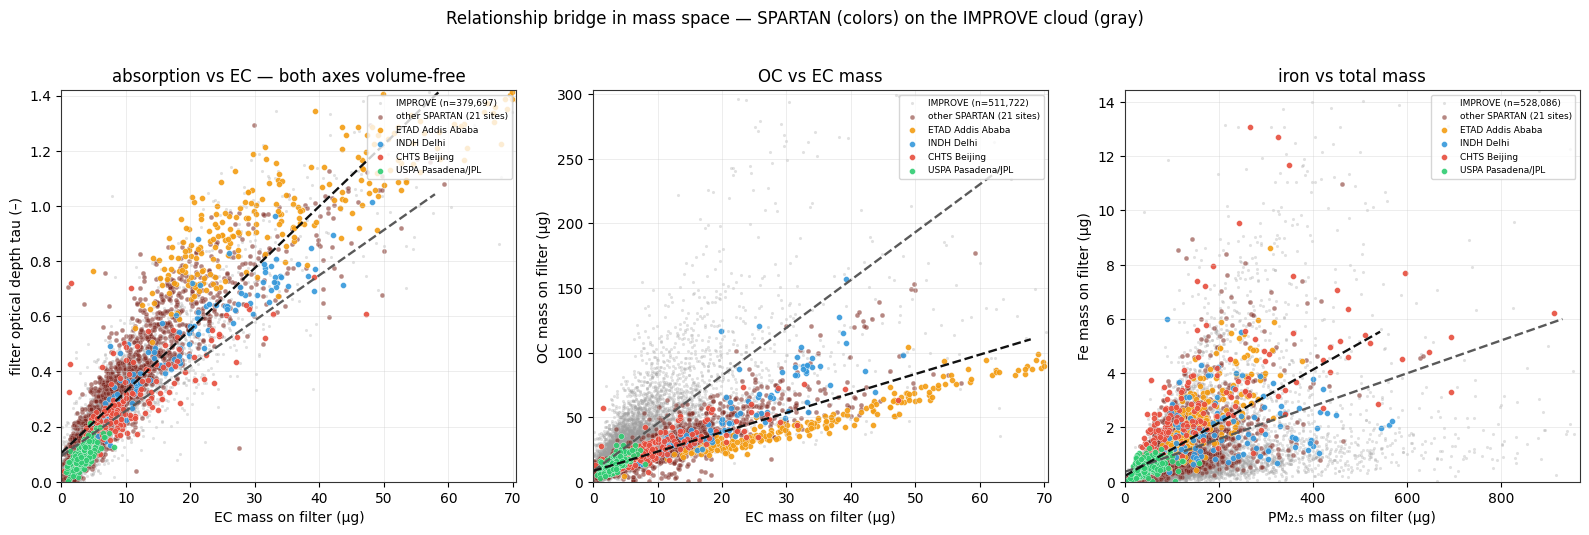

,x,y,network,n,slope,intercept,r_squared,correlation
0,EC_mass_ug,tau_filter,IMPROVE,379697,0.016,0.093,0.616,0.785
1,EC_mass_ug,tau_filter,SPARTAN,2464,0.022,0.104,0.838,0.915
2,EC_mass_ug,OC_mass_ug,IMPROVE,511722,3.704,8.091,0.426,0.653
3,EC_mass_ug,OC_mass_ug,SPARTAN,2456,1.502,8.307,0.732,0.856
4,PM25_mass_ug,Fe_mass_ug,IMPROVE,528086,0.006,0.363,0.186,0.431
5,PM25_mass_ug,Fe_mass_ug,SPARTAN,2472,0.010,0.215,0.358,0.598


In [6]:
def bridge_panel(ax, xcol, ycol, xlabel, ylabel):
    d_imp = both[both["network"].eq("IMPROVE")][[xcol, ycol]].replace([np.inf, -np.inf], np.nan).dropna()
    d_imp = d_imp[(d_imp[xcol] > 0) & (d_imp[ycol] > 0)]
    draw = d_imp.sample(min(len(d_imp), 8000), random_state=0)
    ax.scatter(draw[xcol], draw[ycol], s=5, color=NET_COLORS["IMPROVE"], alpha=0.3,
               linewidths=0, rasterized=True, label=f"IMPROVE (n={len(d_imp):,})")
    d_sp = both[both["network"].eq("SPARTAN")][[xcol, ycol, "site"]].replace(
        [np.inf, -np.inf], np.nan).dropna()
    d_sp = d_sp[(d_sp[xcol] > 0) & (d_sp[ycol] > 0)]
    other = d_sp[~d_sp["site"].isin(CORE4)]
    ax.scatter(other[xcol], other[ycol], s=12, color="#7B241C", alpha=0.55,
               edgecolor="white", linewidth=0.2, label=f"other SPARTAN ({other['site'].nunique()} sites)")
    for s in CORE4:
        g = d_sp[d_sp["site"].eq(s)]
        ax.scatter(g[xcol], g[ycol], s=18, color=SITE_COLORS[s], alpha=0.9,
                   edgecolor="white", linewidth=0.25, label=f"{s} {SITE_NAMES[s]}")
    rows = []
    for name, d in [("IMPROVE", d_imp), ("SPARTAN", d_sp)]:
        st = calculate_regression_stats(d[xcol], d[ycol])
        if st:
            xs = np.linspace(0, d[xcol].quantile(0.995), 50)
            ax.plot(xs, st["slope"] * xs + st["intercept"],
                    color="0.35" if name == "IMPROVE" else "#111111", ls="--", lw=1.7)
            rows.append({"x": xcol, "y": ycol, "network": name, **st})
    ax.set_xlim(0, max(d_imp[xcol].quantile(0.995), d_sp[xcol].quantile(0.995)) * 1.04)
    ax.set_ylim(0, max(d_imp[ycol].quantile(0.995), d_sp[ycol].quantile(0.995)) * 1.04)
    ax.set_xlabel(xlabel); ax.set_ylabel(ylabel)
    ax.legend(fontsize=6.5, loc="upper right")
    return rows


fig, axes = plt.subplots(1, 3, figsize=(16, 5.2))
fit_rows = []
fit_rows += bridge_panel(axes[0], "EC_mass_ug", "tau_filter",
                         "EC mass on filter (µg)", "filter optical depth tau (–)")
axes[0].set_title("absorption vs EC — both axes volume-free")
fit_rows += bridge_panel(axes[1], "EC_mass_ug", "OC_mass_ug",
                         "EC mass on filter (µg)", "OC mass on filter (µg)")
axes[1].set_title("OC vs EC mass")
fit_rows += bridge_panel(axes[2], "PM25_mass_ug", "Fe_mass_ug",
                         "PM₂.₅ mass on filter (µg)", "Fe mass on filter (µg)")
axes[2].set_title("iron vs total mass")
fig.suptitle("Relationship bridge in mass space — SPARTAN (colors) on the IMPROVE cloud (gray)", y=1.02)
fig.tight_layout()
fig.savefig(FIG_DIR / "M4_relationship_bridge_mass.png", dpi=200, bbox_inches="tight")
plt.show()

pd.DataFrame(fit_rows).round(4).to_csv(TAB_DIR / "relationship_fits_mass.csv", index=False)
pd.DataFrame(fit_rows).round(3)

## Figure M5 — derived ratio boxplots (volume-free, unchanged by the mass conversion)

/tmp/ipykernel_4457/435629207.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=ticklabels, showfliers=False, patch_artist=True,


/tmp/ipykernel_4457/435629207.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=ticklabels, showfliers=False, patch_artist=True,


/tmp/ipykernel_4457/435629207.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=ticklabels, showfliers=False, patch_artist=True,


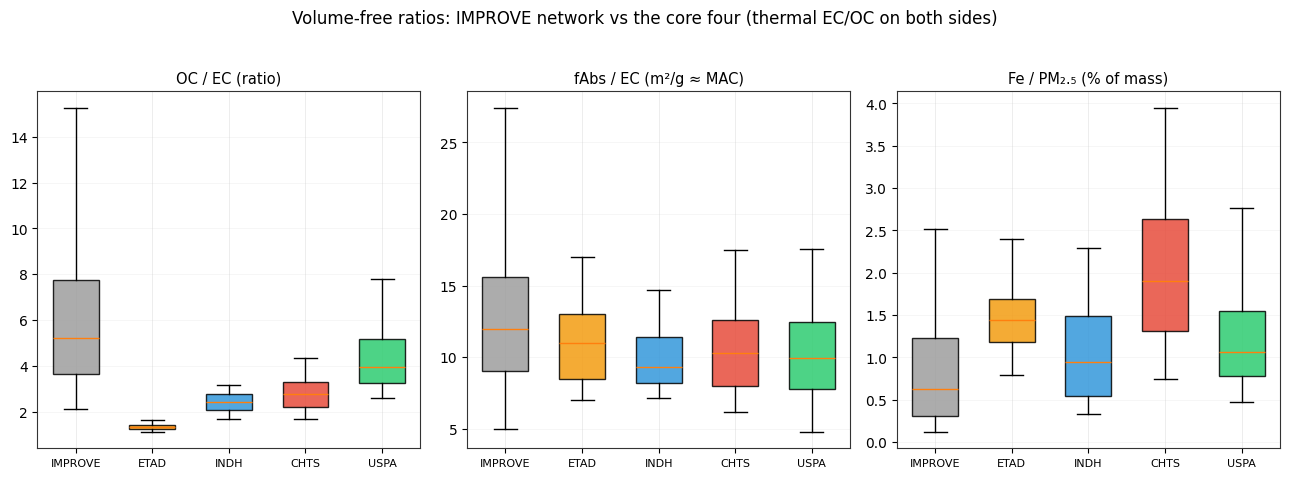

In [7]:
ratios = {"OC_EC": ("OC / EC", "ratio"), "Fabs_EC": ("fAbs / EC", "m²/g ≈ MAC"),
          "Fe_PM": ("Fe / PM₂.₅", "% of mass")}
fig, axes = plt.subplots(1, 3, figsize=(13, 4.6))
rows = []
for ax, (col, (label, unit)) in zip(axes, ratios.items()):
    data, ticklabels, colors = [], [], []
    v = pos(both.loc[both["network"].eq("IMPROVE"), col])
    data.append(v.values); ticklabels.append("IMPROVE"); colors.append(NET_COLORS["IMPROVE"])
    rows.append({"group": "IMPROVE", "ratio": label, "n": len(v), "median": v.median(),
                 "p25": v.quantile(0.25), "p75": v.quantile(0.75)})
    for s in CORE4:
        v = pos(both.loc[both["network"].eq("SPARTAN") & both["site"].eq(s), col])
        data.append(v.values); ticklabels.append(s); colors.append(SITE_COLORS[s])
        rows.append({"group": s, "ratio": label, "n": len(v), "median": v.median(),
                     "p25": v.quantile(0.25), "p75": v.quantile(0.75)})
    bp = ax.boxplot(data, labels=ticklabels, showfliers=False, patch_artist=True,
                    whis=(5, 95), widths=0.6)
    for patch, c in zip(bp["boxes"], colors):
        patch.set_facecolor(c); patch.set_alpha(0.85)
    ax.set_title(f"{label} ({unit})", fontsize=10.5)
    ax.tick_params(axis="x", labelsize=8)
    ax.grid(axis="y", alpha=0.25)
fig.suptitle("Volume-free ratios: IMPROVE network vs the core four (thermal EC/OC on both sides)", y=1.03)
fig.tight_layout()
fig.savefig(FIG_DIR / "M5_ratio_boxplots.png", dpi=200, bbox_inches="tight")
plt.show()

pd.DataFrame(rows).round(3).to_csv(TAB_DIR / "ratio_stats.csv", index=False)

## Read-out

- Total deposits genuinely overlap (M1–M3, PM2.5 panel) — Ann's "mass is not so different" point, now shown
  per quantity with no log axes.
- The EC mass and tau panels are where SPARTAN escapes the IMPROVE envelope, and M4's first panel shows the
  bridge cleanly: at the same EC mass, the SPARTAN cloud (especially Addis, orange) carries more optical depth.
- The ratio panels (M5) are identical in meaning to the old fig05 but restyled; they are untouched by the
  mass conversion since volume divides out.
- IMPROVE pre-2015 rows use site-median-flow estimated volumes (~70% of rows; flagged in `coverage_summary.csv`)
  so the discontinued urban sites — most of the Addis-analog candidates — stay in the comparison.
